# Data Access Utilities

This notebook demonstrates how to access, subset, and export SRM downscaling outputs for impact modeling. 

**Contents:**
1. Prerequisites and Setup
2. Loading and Exploring the Data Catalog
3. **Spatial Subsetting**: Point lookup, bounding box, country/region mask
4. Temporal Subsetting
5. Variable Selection and Transforms 
6. Export to NetCDF/CSV/Parquet

## 1. Prerequisites and Setup

Install dependencies if needed:
```bash
TODO
```

## Workflow Overview

This notebook follows a **modular pipeline approach**. Each section builds on the previous one:

```
1. Load Catalog → 2. Select Datasets → 3. Spatial Subset → 4. Temporal Subset → 5. Transform Variables → 6. Export
```

**How to use this notebook:**

- **Cells marked with "CUSTOMIZE"**: These contain parameters you should modify for your specific use case (e.g., selecting variables, choosing a location)
- **Cells marked with "No modification needed"**: These apply the operations using your parameters - run them as-is
- **Helper function cells**: Reusable code you can use in your own workflows

**Chaining operations**: After each section, you'll have a dataset variable (e.g., `ds`, `ds_clipped`, `ds_subset`) that you can pass to the next section. You can skip sections you don't need or run them in different orders.

In [1]:
import geopandas as gpd
import intake
import xproj  # noqa - enables .proj accessor

## 2. Loading and Exploring the Data Catalog

We use `intake-esm` to access the CMIP6 downscaled data catalog. This allows us to search and filter datasets by various attributes.

**📍 What you'll accomplish in this section:**
- Load the full SRM downscaling data catalog
- Filter the catalog by downscaling method, variable, and experiment
- Extract a dictionary of datasets (`dsets`) to work with in the rest of the notebook

**Available options:**
- **Downscaling method**: `DeepSD-BC`, `GARD-SVM`, `MACA`, etc.
- **Variables**: `pr` (precipitation), `tasmax` (max temp), `tasmin` (min temp), `hurs` (humidity), etc.
- **Experiments**: `historical`, `ssp245`, `ssp370`, `ssp585`, etc.

**📤 Output**: A dictionary called `dsets` containing your selected datasets, which you'll use in sections 3-6.

In [2]:
# ===== No modification needed - loads the full catalog =====
cat = intake.open_esm_datastore(
    "https://rice1.osn.mghpcc.org/carbonplan/cp-cmip/version1/catalog/osn-rechunked-global-downscaled-cmip6.json"
)
cat = cat.search(timescale="month")
cat

,unique
activity_id,2
institution_id,7
source_id,6
experiment_id,4
member_id,1
timescale,1
variable_id,3
method,5
downscaled_daily_data_uri,113
version,1


In [3]:
# View the full catalog as a table (optional - no modification needed)
cat.df

,activity_id,institution_id,source_id,experiment_id,member_id,timescale,variable_id,method,downscaled_daily_data_uri,version
0,CMIP,CCCma,CanESM5,historical,r1i1p1f1,month,pr,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
1,CMIP,CCCma,CanESM5,historical,r1i1p1f1,month,tasmax,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
2,CMIP,CCCma,CanESM5,historical,r1i1p1f1,month,tasmin,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
3,CMIP,MRI,MRI-ESM2-0,historical,r1i1p1f1,month,pr,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
4,CMIP,MRI,MRI-ESM2-0,historical,r1i1p1f1,month,tasmax,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
...,...,...,...,...,...,...,...,...,...,...
108,ScenarioMIP,MRI,MRI-ESM2-0,ssp585,r1i1p1f1,month,pr,MACA,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
109,ScenarioMIP,MRI,MRI-ESM2-0,ssp585,r1i1p1f1,month,tasmax,MACA,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
110,ScenarioMIP,NCC,NorESM2-LM,ssp245,r1i1p1f1,month,pr,MACA,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
111,ScenarioMIP,NCC,NorESM2-LM,ssp245,r1i1p1f1,month,tasmax,MACA,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1


### Selecting Your Datasets

**🔧 Action required**: Customize the selection criteria below to choose which datasets you want to work with.

In [4]:
# ===== CUSTOMIZE YOUR SELECTION HERE =====
# Change these values to select the datasets you want to work with

downscaling_method = "DeepSD-BC"  # Options: "DeepSD-BC", "GARD-SVM", "MACA", etc.
variables = ["pr", "tasmax"]  # Options: "pr", "tasmax", "tasmin", "hurs", etc.
experiments = ["historical"]  # Options: "historical", "ssp245", "ssp370", "ssp585", etc.

# ==========================================

In [5]:
# ===== No modification needed - applies your selection =====
cat_subset = cat.search(method=downscaling_method, variable_id=variables, experiment_id=experiments)
cat_subset

,unique
activity_id,1
institution_id,2
source_id,2
experiment_id,1
member_id,1
timescale,1
variable_id,2
method,1
downscaled_daily_data_uri,4
version,1


In [6]:
# View your subset as a table (optional - no modification needed)
cat_subset.df

,activity_id,institution_id,source_id,experiment_id,member_id,timescale,variable_id,method,downscaled_daily_data_uri,version
0,CMIP,CCCma,CanESM5,historical,r1i1p1f1,month,pr,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
1,CMIP,CCCma,CanESM5,historical,r1i1p1f1,month,tasmax,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
2,CMIP,MRI,MRI-ESM2-0,historical,r1i1p1f1,month,pr,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1
3,CMIP,MRI,MRI-ESM2-0,historical,r1i1p1f1,month,tasmax,DeepSD-BC,https://rice1.osn.mghpcc.org/carbonplan/cp-cmi...,v1


In [7]:
# ===== No modification needed - creates the dataset dictionary =====
dsets = cat_subset.to_dataset_dict()
dsets


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.timescale.method'


<div><progress max="2" value="2"></progress> 100.00% [2/2 00:01&lt;00:00]</div>

{'CMIP.MRI.MRI-ESM2-0.historical.month.DeepSD-BC': <xarray.Dataset> Size: 6GB
 Dimensions:    (member_id: 1, time: 780, lat: 720, lon: 1440)
 Coordinates:
   * member_id  (member_id) object 8B 'r1i1p1f1'
   * time       (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
   * lat        (lat) float64 6kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
   * lon        (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
 Data variables:
     pr         (member_id, time, lat, lon) float32 3GB dask.array<chunksize=(1, 780, 144, 288), meta=np.ndarray>
     tasmax     (member_id, time, lat, lon) float32 3GB dask.array<chunksize=(1, 780, 144, 288), meta=np.ndarray>
 Attributes: (12/26)
     Conventions:                      CF-1.8
     activity_id:                      CMIP
     cmip6_downscaling_contact:        hello@carbonplan.org
     cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
     cmip6_downscaling_institution:    CarbonPlan
     cmip6_dow

## 3. Spatial Subsetting

This section demonstrates three methods for spatial subsetting:
1. **Point lookup**: Extract a time series at a specific lat/lon location
2. **Bounding box**: Subset to a rectangular region
3. **Country/region mask**: Clip to a country or administrative boundary using shapefiles

**📍 What you'll accomplish in this section:**
- Reduce the global dataset to a specific geographic area of interest
- Choose from three spatial subsetting methods based on your needs

**🔀 Choose your method** (you can use just one or combine them):
- **→ Section 3.1 (Point Lookup)**: Extract time series for specific lat/lon coordinates (e.g., for cities or measurement sites)
- **→ Section 3.2 (Bounding Box)**: Get data for a rectangular region defined by min/max lat/lon
- **→ Section 3.3 (Country/Region)**: Clip data to country or administrative boundaries using shapefiles

**📤 Output**: A spatially-subsetted dataset (e.g., `ds_point`, `ds_bbox`, or `ds_clipped`) that you can pass to Section 4 for temporal subsetting.

**💡 Tip**: If you want data for the full global extent, skip this section and go directly to Section 4.

In [8]:
# ===== No modification needed - extracts one dataset to work with =====
# This selects the first dataset from your catalog subset
ds_key = list(dsets.keys())[0]
print(f"Working with dataset: {ds_key}")
ds = dsets[ds_key]
ds

Working with dataset: CMIP.MRI.MRI-ESM2-0.historical.month.DeepSD-BC


<xarray.Dataset> Size: 6GB
Dimensions:    (member_id: 1, time: 780, lat: 720, lon: 1440)
Coordinates:
  * member_id  (member_id) object 8B 'r1i1p1f1'
  * time       (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
  * lat        (lat) float64 6kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon        (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    pr         (member_id, time, lat, lon) float32 3GB dask.array<chunksize=(1, 780, 144, 288), meta=np.ndarray>
    tasmax     (member_id, time, lat, lon) float32 3GB dask.array<chunksize=(1, 780, 144, 288), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

### 3.1 Point Lookup

**Use this method if**: You want time series data for specific locations (e.g., cities, weather stations, project sites).

**🔧 Action required**: Specify your target coordinates in the next cell.

In [9]:
# ===== CUSTOMIZE: Set your target location =====
target_lat = 37.7749  # Latitude of your point of interest
target_lon = -122.4194  # Longitude of your point of interest
# ===============================================

# No modification needed below - extracts the point data
ds_point_nearest = ds.sel(lat=target_lat, lon=target_lon, method="nearest")
print(f"Point subset shape: {dict(ds_point_nearest.sizes)}")
ds_point_nearest

Point subset shape: {'member_id': 1, 'time': 780}


<xarray.Dataset> Size: 13kB
Dimensions:    (member_id: 1, time: 780)
Coordinates:
  * member_id  (member_id) object 8B 'r1i1p1f1'
  * time       (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
    lat        float64 8B 37.88
    lon        float64 8B -122.4
Data variables:
    pr         (member_id, time) float32 3kB dask.array<chunksize=(1, 780), meta=np.ndarray>
    tasmax     (member_id, time) float32 3kB dask.array<chunksize=(1, 780), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

In [10]:
# ===== OPTIONAL: Extract multiple points at once =====
# Customize the locations dictionary below for your sites

locations = {
    "San Francisco": (37.7749, -122.4194),
    "Los Angeles": (34.0522, -118.2437),
    "Seattle": (47.6062, -122.3321),
}

# No modification needed below
point_data = {}
for name, (lat, lon) in locations.items():
    point_data[name] = ds.sel(lat=lat, lon=lon, method="nearest")
    print(f"{name}: lat={point_data[name].lat.values:.2f}, lon={point_data[name].lon.values:.2f}")

San Francisco: lat=37.88, lon=-122.38
Los Angeles: lat=34.12, lon=-118.12
Seattle: lat=47.62, lon=-122.38


### 3.2 Bounding Box Subset

**Use this method if**: You want data for a rectangular region (e.g., a state, watershed, or study area).

**🔧 Action required**: Specify your bounding box coordinates in the next cell.

In [11]:
# ===== CUSTOMIZE: Set your bounding box =====
bbox = {
    "lon_min": -124.5,  # Western boundary
    "lon_max": -114.0,  # Eastern boundary
    "lat_min": 32.5,  # Southern boundary
    "lat_max": 42.0,  # Northern boundary
}
# ============================================

# No modification needed below - applies the bounding box
ds_bbox = ds.sel(
    lat=slice(bbox["lat_min"], bbox["lat_max"]), lon=slice(bbox["lon_min"], bbox["lon_max"])
)

print(f"Original shape: lat={ds.sizes.get('lat', 'N/A')}, lon={ds.sizes.get('lon', 'N/A')}")
print(f"Subset shape: lat={ds_bbox.sizes.get('lat', 'N/A')}, lon={ds_bbox.sizes.get('lon', 'N/A')}")
ds_bbox

Original shape: lat=720, lon=1440
Subset shape: lat=38, lon=42


<xarray.Dataset> Size: 10MB
Dimensions:    (member_id: 1, time: 780, lat: 38, lon: 42)
Coordinates:
  * member_id  (member_id) object 8B 'r1i1p1f1'
  * time       (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
  * lat        (lat) float64 304B 32.62 32.88 33.12 33.38 ... 41.38 41.62 41.88
  * lon        (lon) float64 336B -124.4 -124.1 -123.9 ... -114.6 -114.4 -114.1
Data variables:
    pr         (member_id, time, lat, lon) float32 5MB dask.array<chunksize=(1, 780, 38, 42), meta=np.ndarray>
    tasmax     (member_id, time, lat, lon) float32 5MB dask.array<chunksize=(1, 780, 38, 42), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

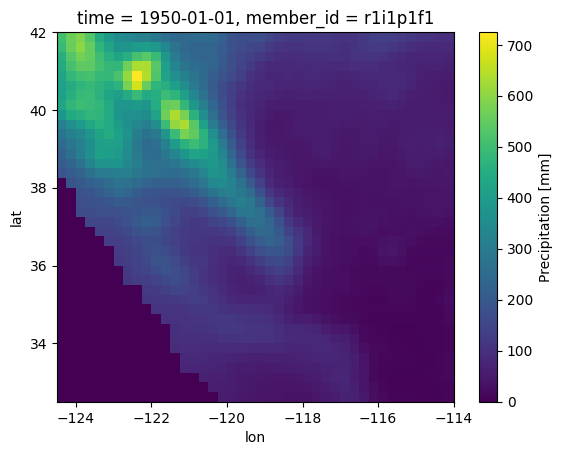

In [12]:
# ===== No modification needed - visualizes your subset =====
ds_bbox.pr.isel(time=0).squeeze().plot();

Western US subset: {'member_id': 1, 'time': 780, 'lat': 72, 'lon': 92}


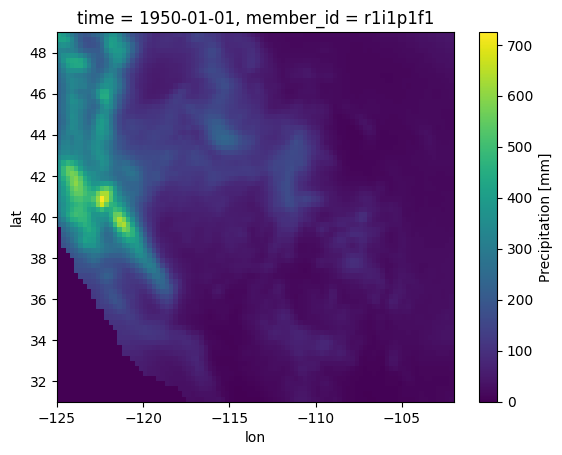

In [13]:
# ===== Helper function - can be reused in your workflows =====
def subset_bbox(ds, lon_min, lon_max, lat_min, lat_max):
    """
    Subset a dataset to a bounding box.

    Parameters
    ----------
    ds : xarray.Dataset
        Input dataset with lat/lon coordinates
    lon_min, lon_max : float
        Longitude bounds
    lat_min, lat_max : float
        Latitude bounds

    Returns
    -------
    xarray.Dataset
        Subsetted dataset
    """
    # Handle both ascending and descending latitude coordinates
    lat_slice = slice(lat_min, lat_max) if ds.lat[0] < ds.lat[-1] else slice(lat_max, lat_min)
    lon_slice = slice(lon_min, lon_max) if ds.lon[0] < ds.lon[-1] else slice(lon_max, lon_min)

    return ds.sel(lat=lat_slice, lon=lon_slice)


# Example usage (no modification needed)
ds_western_us = subset_bbox(ds, lon_min=-125, lon_max=-102, lat_min=31, lat_max=49)
print(f"Western US subset: {dict(ds_western_us.sizes)}")
ds_western_us.pr.squeeze().isel(time=0).plot();

### 3.3 Country/Region Mask

**Use this method if**: You want data clipped to country borders or administrative boundaries (e.g., for national or regional assessments).

**🔧 Action required**: Specify your country/region name or provide a custom shapefile.

In [14]:
# ===== No modification needed - loads country boundaries =====
import pooch

countries_url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
countries_path = pooch.retrieve(countries_url, known_hash=None, processor=pooch.Unzip())
countries = gpd.read_file([p for p in countries_path if p.endswith(".shp")][0])
print(f"Available countries: {countries.shape[0]}")
countries[["NAME", "CONTINENT"]].head(10)

Available countries: 177


,NAME,CONTINENT
0,Fiji,Oceania
1,Tanzania,Africa
2,W. Sahara,Africa
3,Canada,North America
4,United States of America,North America
5,Kazakhstan,Asia
6,Uzbekistan,Asia
7,Papua New Guinea,Oceania
8,Indonesia,Asia
9,Argentina,South America


In [15]:
# ===== No modification needed - assigns CRS to dataset =====
ds_with_crs = ds.proj.assign_crs(spatial_ref="epsg:4326")
ds_with_crs

<xarray.Dataset> Size: 6GB
Dimensions:      (member_id: 1, time: 780, lat: 720, lon: 1440)
Coordinates:
  * member_id    (member_id) object 8B 'r1i1p1f1'
  * time         (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
  * lat          (lat) float64 6kB -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon          (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * spatial_ref  int64 8B 0
Data variables:
    pr           (member_id, time, lat, lon) float32 3GB dask.array<chunksize=(1, 780, 144, 288), meta=np.ndarray>
    tasmax       (member_id, time, lat, lon) float32 3GB dask.array<chunksize=(1, 780, 144, 288), meta=np.ndarray>
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

Selected country: India
Bounds: [68.17664514  7.96553478 97.40256148 35.49400951]


<Axes: >

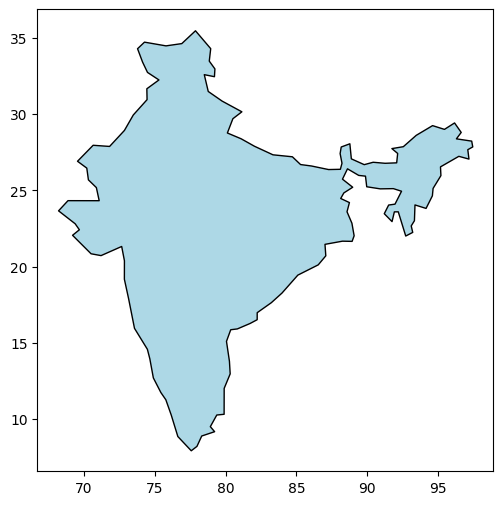

In [16]:
# ===== CUSTOMIZE: Select your country/region =====
country_name = "India"  # Change this to your country of interest
# ================================================

# No modification needed below - selects the country
country = countries[countries["NAME"] == country_name]
print(f"Selected country: {country_name}")
print(f"Bounds: {country.total_bounds}")  # [minx, miny, maxx, maxy]
country.plot(figsize=(8, 6), edgecolor="black", facecolor="lightblue")

#### Method 1: Geometry Mask

Create a boolean mask indicating which grid cells fall within the geometry. This is useful when you want to keep the original grid structure.

/Users/andersy005/devel/carbonplan/carbonplan-srm/.venv/lib/python3.13/site-packages/rasterio/features.py:410: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  _rasterize(valid_shapes, out, transform, all_touched, merge_alg)


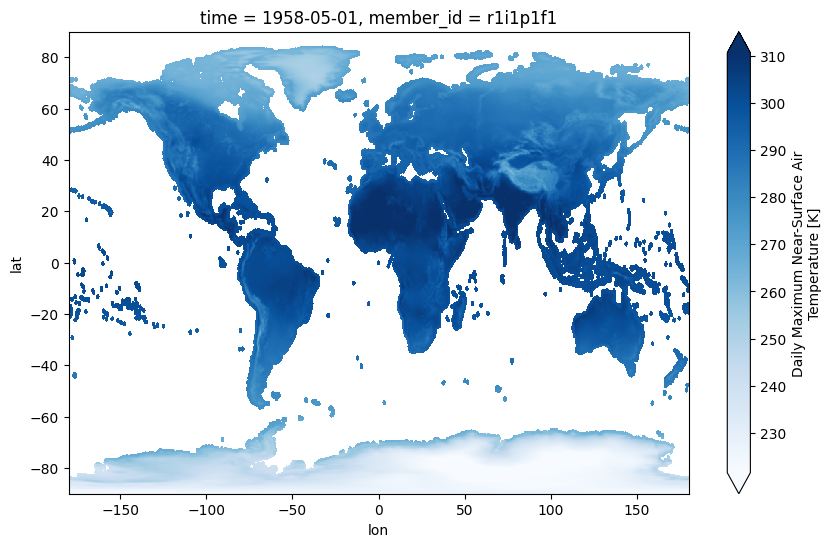

In [17]:
# ===== No modification needed - creates boolean mask and visualizes data =====
from rasterix.rasterize.rasterio import geometry_mask

# Create a mask from the country geometry
mask = geometry_mask(ds_with_crs, country[["geometry"]], xdim="lon", ydim="lat")

# Apply mask to actual data to visualize (shows temperature values for India only)
ds_masked = ds_with_crs.where(mask)
ds_masked["tasmax"].isel(time=100).squeeze().drop_vars("spatial_ref", errors="ignore").plot(
    figsize=(10, 6), robust=True, cmap="Blues"
)

#### Method 2: Geometry Clip (Recommended)

**Most efficient approach**: Clips to geometry bounds and masks values outside. Use this method for most workflows.

In [18]:
# ===== No modification needed - clips to country geometry =====
from rasterix.rasterize.rasterio import geometry_clip

# Clip the dataset to the country geometry
ds_clipped = geometry_clip(
    ds_with_crs, country[["geometry"]], xdim="lon", ydim="lat", clip=True
).drop_indexes("spatial_ref")
print(f"Clipped dataset shape: {dict(ds_clipped.sizes)}")
ds_clipped

Clipped dataset shape: {'member_id': 1, 'time': 780, 'lat': 110, 'lon': 117}


<xarray.Dataset> Size: 80MB
Dimensions:      (member_id: 1, time: 780, lat: 110, lon: 117)
Coordinates:
  * member_id    (member_id) object 8B 'r1i1p1f1'
  * time         (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
  * lat          (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon          (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
    spatial_ref  int64 8B 0
Data variables:
    pr           (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 40, 117), meta=np.ndarray>
    tasmax       (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 40, 117), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

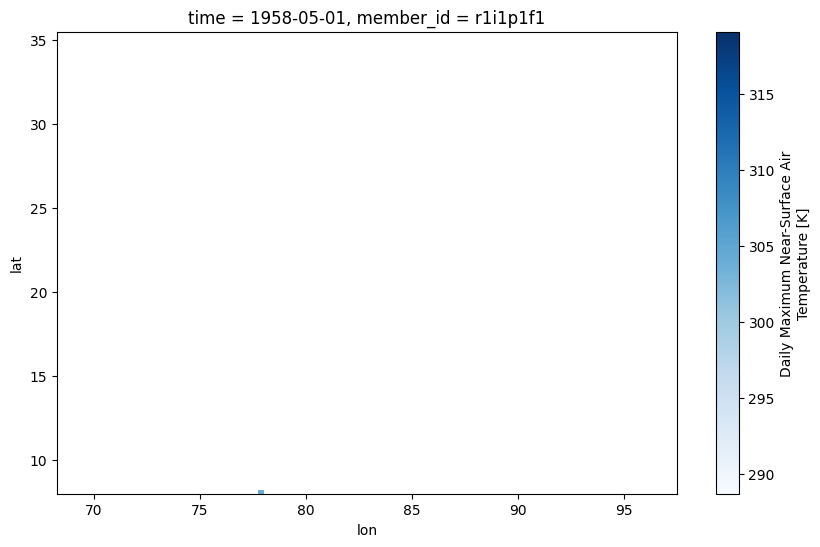

In [19]:
# ===== No modification needed - visualizes clipped data =====
ds_clipped["tasmax"].isel(time=100).squeeze().drop_vars("spatial_ref", errors="ignore").plot(
    figsize=(10, 6), robust=True, cmap="Blues"
)

#### Method 3: Out-of-Core Support with Dask

`rasterix` supports chunked/dask arrays for processing large datasets that don't fit in memory.

**Note on chunking parameters**: The `.chunk({"lat": -1, "lon": 120})` below is a memory optimization strategy:
- `"lat": -1` → preserves existing latitude chunks (do not rechunk)
- `"lon": 120` → splits longitude into 120-element chunks

**You typically don't need to modify these values** — they're optimized for the global dataset structure. Only adjust if you encounter memory issues.

In [20]:
# Chunk the dataset for out-of-core processing
ds_chunked = ds_with_crs.chunk({"lat": -1, "lon": 120})

# geometry_clip works seamlessly with chunked data
ds_clipped_chunked = geometry_clip(ds_chunked, country[["geometry"]], xdim="lon", ydim="lat")
print("Chunked clipped dataset:")
ds_clipped_chunked

Chunked clipped dataset:


<xarray.Dataset> Size: 80MB
Dimensions:      (member_id: 1, time: 780, lat: 110, lon: 117)
Coordinates:
  * member_id    (member_id) object 8B 'r1i1p1f1'
  * time         (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
  * lat          (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon          (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
  * spatial_ref  int64 8B 0
Data variables:
    pr           (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 110, 87), meta=np.ndarray>
    tasmax       (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 110, 87), meta=np.ndarray>
Indexes:
    spatial_ref  CRSIndex (crs=EPSG:4326)
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

### 3.4 Spatial Subsetting Summary

| Method | Use Case | Performance | Package | Covered in |
|--------|----------|-------------|---------|------------|
| **Point (nearest)** | Single location time series | Fast | xarray | Section 3.1 |
| **Point (interp)** | Exact coordinates needed | Moderate | xarray | Section 3.1 |
| **Bounding box** | Rectangular regions | Fast | xarray | Section 3.2 |
| **geometry_mask** | Create boolean mask for geometries | Fast, Dask-aware | rasterix | Section 3.3 |
| **geometry_clip** | Clip to geometry bounds + mask | Fast, Dask-aware | rasterix | Section 3.3 |

**Tips:**
- Always assign CRS to your dataset before using rasterix: `ds.proj.assign_crs(spatial_ref="epsg:4326")`
- Use chunked datasets for large files that don't fit in memory
- `geometry_clip` is recommended for most use cases as it reduces data volume

## 4. Temporal Subsetting

**📍 What you'll accomplish in this section:**
- Filter your dataset to specific time periods (years, months, seasons)
- Resample data to different time frequencies (e.g., monthly to annual)
- Calculate climatologies and time aggregations

**🔀 Choose your method**:
- **→ Section 4.1 (Date Range)**: Select specific years or date ranges
- **→ Section 4.2 (Months/Seasons)**: Filter to specific months or meteorological seasons
- **→ Section 4.3 (Resampling)**: Change time frequency (e.g., monthly to annual)

**📤 Output**: A temporally-filtered dataset (e.g., `ds_1990s`, `ds_summer`, `ds_annual`) ready for variable transforms (Section 5) or export (Section 6).

**💡 Tip**: You can apply temporal subsetting to any dataset from Section 3, or to your original `ds` if you skipped spatial subsetting.

In [21]:
# ===== No modification needed - checks time range =====
# This works with whatever dataset you created in Section 3 (ds_clipped, ds_bbox, ds_point, or ds)
print(f"Time range: {ds_clipped.time.values[0]} to {ds_clipped.time.values[-1]}")
print(f"Total time steps: {ds_clipped.sizes['time']}")

Time range: 1950-01-01T00:00:00.000000000 to 2014-12-01T00:00:00.000000000
Total time steps: 780


### 4.1 Date Range Selection

**Use this method if**: You need data for a specific time period (e.g., historical baseline, specific decade).

**🔧 Action required**: Specify your date range in the next cells.

In [22]:
# ===== CUSTOMIZE: Set your date range =====
start_date = "1990-01-01"
end_date = "1999-12-31"
# ==========================================

# No modification needed below
ds_1990s = ds_clipped.sel(time=slice(start_date, end_date))
print(f"1990s subset: {ds_1990s.sizes['time']} time steps")
print(f"Date range: {ds_1990s.time.values[0]} to {ds_1990s.time.values[-1]}")
ds_1990s

1990s subset: 120 time steps
Date range: 1990-01-01T00:00:00.000000000 to 1999-12-01T00:00:00.000000000


<xarray.Dataset> Size: 12MB
Dimensions:      (member_id: 1, time: 120, lat: 110, lon: 117)
Coordinates:
  * member_id    (member_id) object 8B 'r1i1p1f1'
  * time         (time) datetime64[ns] 960B 1990-01-01 1990-02-01 ... 1999-12-01
  * lat          (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon          (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
    spatial_ref  int64 8B 0
Data variables:
    pr           (member_id, time, lat, lon) float32 6MB dask.array<chunksize=(1, 120, 40, 117), meta=np.ndarray>
    tasmax       (member_id, time, lat, lon) float32 6MB dask.array<chunksize=(1, 120, 40, 117), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

In [23]:
# ===== CUSTOMIZE: Select a single year =====
target_year = "1995"
# ===========================================

# No modification needed below
ds_1995 = ds_clipped.sel(time=target_year)
print(f"Year {target_year}: {ds_1995.sizes['time']} time steps")
ds_1995

Year 1995: 12 time steps


<xarray.Dataset> Size: 1MB
Dimensions:      (member_id: 1, time: 12, lat: 110, lon: 117)
Coordinates:
  * member_id    (member_id) object 8B 'r1i1p1f1'
  * time         (time) datetime64[ns] 96B 1995-01-01 1995-02-01 ... 1995-12-01
  * lat          (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon          (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
    spatial_ref  int64 8B 0
Data variables:
    pr           (member_id, time, lat, lon) float32 618kB dask.array<chunksize=(1, 12, 40, 117), meta=np.ndarray>
    tasmax       (member_id, time, lat, lon) float32 618kB dask.array<chunksize=(1, 12, 40, 117), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

### 4.2 Month and Season Selection

**Use this method if**: You need data for specific months or meteorological seasons (e.g., summer heat analysis, monsoon season).

**🔧 Action required**: Specify months or seasons in the next cells.

In [24]:
# ===== CUSTOMIZE: Select specific months =====
# Months: 1=Jan, 2=Feb, ..., 12=Dec
target_months = [6, 7, 8]  # Summer months (JJA)
# =============================================

# No modification needed below
ds_summer = ds_clipped.sel(time=ds_clipped.time.dt.month.isin(target_months))
print(f"Selected months: {ds_summer.sizes['time']} time steps")

Selected months: 195 time steps


In [25]:
# ===== CUSTOMIZE: Select by season =====
# Options: "DJF" (winter), "MAM" (spring), "JJA" (summer), "SON" (fall)
target_season = "DJF"
# =======================================

# No modification needed below
ds_winter = ds_clipped.sel(time=ds_clipped.time.dt.season == target_season)
print(f"{target_season} season: {ds_winter.sizes['time']} time steps")

DJF season: 195 time steps


In [26]:
# ===== No modification needed - calculates seasonal climatology =====
ds_seasonal_clim = ds_clipped.groupby("time.season").mean("time")
print(f"Seasonal climatology dimensions: {dict(ds_seasonal_clim.sizes)}")
ds_seasonal_clim

Seasonal climatology dimensions: {'season': 4, 'member_id': 1, 'lat': 110, 'lon': 117}


<xarray.Dataset> Size: 414kB
Dimensions:      (season: 4, member_id: 1, lat: 110, lon: 117)
Coordinates:
  * season       (season) object 32B 'DJF' 'JJA' 'MAM' 'SON'
  * member_id    (member_id) object 8B 'r1i1p1f1'
  * lat          (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon          (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
    spatial_ref  int64 8B 0
Data variables:
    pr           (season, member_id, lat, lon) float32 206kB dask.array<chunksize=(4, 1, 40, 117), meta=np.ndarray>
    tasmax       (season, member_id, lat, lon) float32 206kB dask.array<chunksize=(4, 1, 40, 117), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

### 4.3 Temporal Resampling

**Use this method if**: You need to change the time frequency of your data (e.g., monthly to annual averages for trend analysis).

In [27]:
# ===== No modification needed - resamples to annual means =====
ds_annual = ds_clipped.resample(time="YE").mean()
print(f"Annual resampled: {ds_annual.sizes['time']} time steps")

# For precipitation, annual totals are often more useful than means
ds_annual_sum = ds_clipped["pr"].resample(time="YE").sum()
print(f"Annual precipitation totals: {ds_annual_sum.sizes['time']} time steps")

Annual resampled: 65 time steps
Annual precipitation totals: 65 time steps


In [28]:
# ===== Helper function - flexible temporal subsetting =====
def subset_time(ds, start_date=None, end_date=None, months=None, seasons=None):
    """
    Flexible temporal subsetting of a dataset.

    Parameters
    ----------
    ds : xarray.Dataset
        Input dataset with time coordinate
    start_date : str, optional
        Start date in 'YYYY-MM-DD' format
    end_date : str, optional
        End date in 'YYYY-MM-DD' format
    months : list of int, optional
        List of months to select (1-12)
    seasons : list of str, optional
        List of seasons to select ('DJF', 'MAM', 'JJA', 'SON')

    Returns
    -------
    xarray.Dataset
        Temporally subsetted dataset
    """
    result = ds

    # Date range selection
    if start_date or end_date:
        result = result.sel(time=slice(start_date, end_date))

    # Month selection
    if months:
        result = result.sel(time=result.time.dt.month.isin(months))

    # Season selection
    if seasons:
        result = result.sel(time=result.time.dt.season.isin(seasons))

    return result


# Example usage - summer months for 1990-2000 (no modification needed)
ds_summer_90s = subset_time(
    ds_clipped, start_date="1990-01-01", end_date="1999-12-31", months=[6, 7, 8]
)
print(f"Summer 1990s: {ds_summer_90s.sizes['time']} time steps")

Summer 1990s: 30 time steps


### 4.4 Temporal Subsetting Summary

| Method | Use Case | Example |
|--------|----------|---------|
| **Date range** | Specific time period | `ds.sel(time=slice("1990", "2000"))` |
| **Single year** | One year of data | `ds.sel(time="1995")` |
| **Month filter** | Specific months | `ds.sel(time=ds.time.dt.month.isin([6,7,8]))` |
| **Season filter** | Meteorological seasons | `ds.sel(time=ds.time.dt.season=="DJF")` |
| **Resample** | Change time frequency | `ds.resample(time="YE").mean()` |
| **Groupby** | Climatologies | `ds.groupby("time.season").mean()` |

## 5. Variable Selection and Transforms

**📍 What you'll accomplish in this section:**
- Select specific climate variables from your dataset
- Convert units to more standard formats (Kelvin→Celsius, flux→mm/day)
- Calculate derived variables and anomalies

**🔀 Choose your operations**:
- **→ Section 5.1**: Select which variables to keep
- **→ Section 5.2**: Apply unit conversions
- **→ Section 5.3**: Compute derived variables or anomalies

**📤 Output**: A transformed dataset ready for export (Section 6) or further analysis.

**💡 Tip**: If your dataset already has the variables and units you need, skip to Section 6.

### 5.1 Variable Selection

Select specific variables from a multi-variable dataset.

In [29]:
# ===== No modification needed - view available variables =====
print("Available variables:")
for var in ds_clipped.data_vars:
    print(f"  - {var}: {ds_clipped[var].attrs.get('long_name', 'No description')}")

Available variables:
  - pr: Precipitation
  - tasmax: Daily Maximum Near-Surface Air Temperature


In [30]:
# ===== CUSTOMIZE: Select specific variables =====
# For a single variable (uncomment if needed):
# selected_var = "tasmax"
# tasmax = ds_clipped[selected_var]

# For multiple variables:
variables_to_keep = ["tasmax", "pr"]
# ================================================

# No modification needed below
ds_temp_vars = ds_clipped[variables_to_keep]
print(f"Selected variables: {list(ds_temp_vars.data_vars)}")

Selected variables: ['tasmax', 'pr']


### 5.2 Unit Conversions

Common unit conversions for climate data.

In [31]:
# ===== No modification needed - check current units =====
print(f"tasmax units: {ds_clipped['tasmax'].attrs.get('units', 'unknown')}")
print(f"pr units: {ds_clipped['pr'].attrs.get('units', 'unknown')}")

tasmax units: K
pr units: mm


In [32]:
# ===== 📖 Helper function - temperature conversion =====
def kelvin_to_celsius(da):
    """Convert temperature from Kelvin to Celsius."""
    da_celsius = da - 273.15
    da_celsius.attrs = da.attrs.copy()
    da_celsius.attrs["units"] = "°C"
    return da_celsius


# No modification needed - applies conversion
tasmax_celsius = kelvin_to_celsius(ds_clipped["tasmax"])
print(f"Original mean: {float(ds_clipped['tasmax'].mean()):.2f} K")
print(f"Converted mean: {float(tasmax_celsius.mean()):.2f} °C")

Original mean: 301.68 K
Converted mean: 28.53 °C


In [33]:
# ===== Helper function - precipitation conversion =====
def precip_to_mm_day(da):
    """Convert precipitation from kg m-2 s-1 to mm/day."""
    # 1 kg/m2/s = 86400 mm/day (since 1 kg/m2 = 1 mm for water)
    da_mm = da * 86400
    da_mm.attrs = da.attrs.copy()
    da_mm.attrs["units"] = "mm/day"
    return da_mm


# No modification needed - applies conversion
pr_mm = precip_to_mm_day(ds_clipped["pr"])
print(f"Original mean: {float(ds_clipped['pr'].mean()):.2e} kg m-2 s-1")
print(f"Converted mean: {float(pr_mm.mean()):.2f} mm/day")

Original mean: 7.12e+01 kg m-2 s-1
Converted mean: 6149529.00 mm/day


### 5.3 Computing Derived Variables

Calculate new variables from existing ones.

In [34]:
# ===== No modification needed - creates dataset with converted units =====
ds_converted = ds_clipped.copy()

# Add converted variables
ds_converted["tasmax_celsius"] = kelvin_to_celsius(ds_converted["tasmax"])
ds_converted["pr_mm_day"] = precip_to_mm_day(ds_converted["pr"])

print("Dataset with converted variables:")
print(f"Variables: {list(ds_converted.data_vars)}")
ds_converted

Dataset with converted variables:
Variables: ['pr', 'tasmax', 'tasmax_celsius', 'pr_mm_day']


<xarray.Dataset> Size: 161MB
Dimensions:         (member_id: 1, time: 780, lat: 110, lon: 117)
Coordinates:
  * member_id       (member_id) object 8B 'r1i1p1f1'
  * time            (time) datetime64[ns] 6kB 1950-01-01 ... 2014-12-01
  * lat             (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon             (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
    spatial_ref     int64 8B 0
Data variables:
    pr              (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 40, 117), meta=np.ndarray>
    tasmax          (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 40, 117), meta=np.ndarray>
    tasmax_celsius  (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 40, 117), meta=np.ndarray>
    pr_mm_day       (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 780, 40, 117), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

In [35]:
# ===== CUSTOMIZE: Set baseline period for anomalies =====
baseline_start = "1980-01-01"
baseline_end = "2000-12-31"
# ========================================================

# No modification needed below - calculates anomalies
baseline = ds_clipped.sel(time=slice(baseline_start, baseline_end))
baseline_clim = baseline.groupby("time.month").mean("time")

# Calculate anomalies
anomalies = ds_clipped.groupby("time.month") - baseline_clim
print(f"Anomalies computed relative to {baseline_start} to {baseline_end}")
anomalies

Anomalies computed relative to 1980-01-01 to 2000-12-31


<xarray.Dataset> Size: 80MB
Dimensions:      (lat: 110, lon: 117, time: 780, member_id: 1)
Coordinates:
  * lat          (lat) float64 880B 8.125 8.375 8.625 ... 34.88 35.12 35.38
  * lon          (lon) float64 936B 68.38 68.62 68.88 ... 96.88 97.12 97.38
  * time         (time) datetime64[ns] 6kB 1950-01-01 1950-02-01 ... 2014-12-01
  * member_id    (member_id) object 8B 'r1i1p1f1'
    spatial_ref  (time) int64 6kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    month        (time) int64 6kB 1 2 3 4 5 6 7 8 9 10 ... 4 5 6 7 8 9 10 11 12
Data variables:
    pr           (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 12, 40, 117), meta=np.ndarray>
    tasmax       (member_id, time, lat, lon) float32 40MB dask.array<chunksize=(1, 12, 40, 117), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      CMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.MRI.MRI-ESM2-0.historical.month.De...

### 5.4 Applying Custom Transformations

Apply custom functions across the dataset using xarray's `apply_ufunc` or simple arithmetic.

In [36]:
import numpy as np

# ===== CUSTOMIZE: Set rolling window size =====
window_months = 12  # Number of months for rolling average
# ==============================================

# No modification needed below
tasmax_rolling = ds_clipped["tasmax"].rolling(time=window_months, center=True).mean()
print(f"Rolling mean shape: {dict(tasmax_rolling.sizes)}")

# Calculate percentiles (no modification needed)
tasmax_p95 = ds_clipped["tasmax"].quantile(0.95, dim="time")
print(f"95th percentile shape: {dict(tasmax_p95.sizes)}")

Rolling mean shape: {'member_id': 1, 'time': 780, 'lat': 110, 'lon': 117}
95th percentile shape: {'member_id': 1, 'lat': 110, 'lon': 117}


In [37]:
# ===== 📖 Helper function - standardize data =====
def standardize(da, dim="time"):
    """Standardize data to z-scores along a dimension."""
    mean = da.mean(dim=dim)
    std = da.std(dim=dim)
    return (da - mean) / std


# No modification needed - applies standardization
tasmax_zscore = standardize(ds_clipped["tasmax"])
print(f"Z-score mean: {float(tasmax_zscore.mean()):.6f} (should be ~0)")
print(f"Z-score std: {float(tasmax_zscore.std()):.6f} (should be ~1)")

Z-score mean: 0.000062 (should be ~0)
Z-score std: 1.000000 (should be ~1)


## 6. Export to NetCDF/CSV/Parquet

**📍 What you'll accomplish in this section:**
- Export your processed data to standard file formats
- Choose the right format for your use case and tools

**🔀 Choose your export format**:
- **→ Section 6.1 (NetCDF)**: For gridded data, preserves all metadata - best for climate science workflows
- **→ Section 6.2 (CSV)**: For point data or simple tabular exports - works with Excel and other tools
- **→ Section 6.3 (Parquet)**: For large tabular datasets - efficient compression and fast I/O

**💡 Tip**: You can export at any stage - after spatial subsetting, temporal filtering, or variable transforms. Just use whatever dataset variable you created (e.g., `ds_clipped`, `ds_1990s`, `ds_converted`).

In [38]:
# ===== CUSTOMIZE: Set your output directory =====
from pathlib import Path

# Change this path to your desired location (relative or absolute path)
# Current setting saves files in an 'exports' folder in the current directory
output_dir = Path("./exports")
# ================================================

# No modification needed below
output_dir.mkdir(exist_ok=True)
print(f"Output directory: {output_dir.absolute()}")

Output directory: /Users/andersy005/devel/carbonplan/carbonplan-srm/data-access-notebooks/exports


### 6.1 Export to NetCDF

NetCDF is the standard format for gridded climate data, preserving coordinates, attributes, and metadata.

In [39]:
# ===== CUSTOMIZE: Set export time range =====
export_start = "1990-01-01"
export_end = "1995-12-31"
# ===========================================

# No modification needed below - prepares subset for export
ds_export = ds_clipped.sel(time=slice(export_start, export_end))
print(f"Export dataset shape: {dict(ds_export.sizes)}")

# ===== CUSTOMIZE: Set output filename =====
netcdf_filename = "india_climate_1990-1995.nc"
# ==========================================

# No modification needed below
netcdf_path = output_dir / netcdf_filename
ds_export.to_netcdf(netcdf_path)
print(f"Saved to: {netcdf_path}")
print(f"File size: {netcdf_path.stat().st_size / 1024:.1f} KB")

Export dataset shape: {'member_id': 1, 'time': 72, 'lat': 110, 'lon': 117}
Saved to: exports/india_climate_1990-1995.nc
File size: 7260.3 KB


In [40]:
# ===== No modification needed - export with compression (recommended) =====
encoding = {var: {"zlib": True, "complevel": 5} for var in ds_export.data_vars}

netcdf_compressed_path = output_dir / "india_climate_1990-1995_compressed.nc"
ds_export.to_netcdf(netcdf_compressed_path, encoding=encoding)
print(f"Compressed file size: {netcdf_compressed_path.stat().st_size / 1024:.1f} KB")

Compressed file size: 37.2 KB


### 6.2 Export to CSV

CSV format is useful for point data or when sharing with non-Python tools. Best suited for 1D or 2D data.

In [41]:
# ===== CUSTOMIZE: Set point location for CSV export =====
point_lat = 28.6  # Delhi, India
point_lon = 77.2
# ========================================================

# No modification needed below - extracts point and converts to DataFrame
point_data = ds_export.sel(lat=point_lat, lon=point_lon, method="nearest")
df_point = point_data.to_dataframe().reset_index()
print(f"Point data shape: {df_point.shape}")
df_point.head()

Point data shape: (72, 7)


,member_id,time,pr,tasmax,lat,lon,spatial_ref
0,r1i1p1f1,1990-01-01,NaN,NaN,28.625,77.125,0
1,r1i1p1f1,1990-02-01,NaN,NaN,28.625,77.125,0
2,r1i1p1f1,1990-03-01,NaN,NaN,28.625,77.125,0
3,r1i1p1f1,1990-04-01,NaN,NaN,28.625,77.125,0
4,r1i1p1f1,1990-05-01,NaN,NaN,28.625,77.125,0


In [42]:
# ===== CUSTOMIZE: Set CSV filename =====
csv_filename = "delhi_climate_1990-1995.csv"
# =======================================

# No modification needed below
csv_path = output_dir / csv_filename
df_point.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")
print(f"File size: {csv_path.stat().st_size / 1024:.1f} KB")

Saved to: exports/delhi_climate_1990-1995.csv
File size: 2.7 KB


In [43]:
# ===== No modification needed - exports area-weighted regional mean =====
weights = np.cos(np.deg2rad(ds_export.lat))
ds_weighted_mean = ds_export.weighted(weights).mean(dim=["lat", "lon"])

df_regional = ds_weighted_mean.to_dataframe().reset_index()
csv_regional_path = output_dir / "india_regional_mean_1990-1995.csv"
df_regional.to_csv(csv_regional_path, index=False)
print(f"Regional mean saved to: {csv_regional_path}")
df_regional.head()

Regional mean saved to: exports/india_regional_mean_1990-1995.csv


,time,member_id,spatial_ref,pr,tasmax
0,1990-01-01,r1i1p1f1,0,11.947864,301.705444
1,1990-02-01,r1i1p1f1,0,11.551138,301.760590
2,1990-03-01,r1i1p1f1,0,12.191964,302.389374
3,1990-04-01,r1i1p1f1,0,29.719397,303.072571
4,1990-05-01,r1i1p1f1,0,19.418512,303.050110


### 6.3 Export to Parquet

Parquet is an efficient columnar format ideal for large tabular datasets. It's faster to read/write than CSV and supports compression.

In [44]:
# ===== No modification needed - flattens gridded data to DataFrame =====
# Note: Using just 1 year for demo to keep file size manageable
ds_small = ds_export.sel(time=slice("1990-01-01", "1990-12-31"))
df_grid = ds_small.to_dataframe().reset_index()
print(f"Flattened grid shape: {df_grid.shape}")
df_grid.head()

Flattened grid shape: (154440, 7)


,member_id,time,lat,lon,pr,tasmax,spatial_ref
0,r1i1p1f1,1990-01-01,8.125,68.375,NaN,NaN,0
1,r1i1p1f1,1990-01-01,8.125,68.625,NaN,NaN,0
2,r1i1p1f1,1990-01-01,8.125,68.875,NaN,NaN,0
3,r1i1p1f1,1990-01-01,8.125,69.125,NaN,NaN,0
4,r1i1p1f1,1990-01-01,8.125,69.375,NaN,NaN,0


In [45]:
# ===== CUSTOMIZE: Set Parquet filename =====
parquet_filename = "india_climate_1990.parquet"
# ===========================================

# No modification needed below
parquet_path = output_dir / parquet_filename
df_grid.to_parquet(parquet_path, index=False, compression="snappy")
print(f"Saved to: {parquet_path}")
print(f"File size: {parquet_path.stat().st_size / 1024:.1f} KB")

Saved to: exports/india_climate_1990.parquet
File size: 14.8 KB


In [46]:
# ===== No modification needed - compares file sizes =====
csv_comparison_path = output_dir / "india_climate_1990.csv"
df_grid.to_csv(csv_comparison_path, index=False)

print("File size comparison:")
print(f"  CSV:     {csv_comparison_path.stat().st_size / 1024:.1f} KB")
print(f"  Parquet: {parquet_path.stat().st_size / 1024:.1f} KB")
print(
    f"  Parquet is {csv_comparison_path.stat().st_size / parquet_path.stat().st_size:.1f}x smaller"
)

File size comparison:
  CSV:     5720.5 KB
  Parquet: 14.8 KB
  Parquet is 385.5x smaller


### 6.4 Export Format Summary

| Format | Best For | Pros | Cons |
|--------|----------|------|------|
| **NetCDF** | Gridded climate data | Preserves coordinates, metadata, CF-compliant | Requires specialized tools to read |
| **CSV** | Point data, simple sharing | Universal compatibility | Large files, slow I/O, no compression |
| **Parquet** | Large tabular datasets | Fast I/O, compressed, columnar | Requires pyarrow/fastparquet |

**Tips:**
- Use NetCDF for gridded data that needs to preserve spatial structure
- Use CSV for small datasets or when sharing with Excel/non-Python users
- Use Parquet for large tabular datasets or data pipelines

In [47]:
# ===== No modification needed - lists all exported files =====
print("Exported files:")
for f in sorted(output_dir.glob("*")):
    print(f"  {f.name}: {f.stat().st_size / 1024:.1f} KB")

Exported files:
  delhi_climate_1990-1995.csv: 2.7 KB
  india_climate_1990-1995.nc: 7260.3 KB
  india_climate_1990-1995_compressed.nc: 37.2 KB
  india_climate_1990.csv: 5720.5 KB
  india_climate_1990.parquet: 14.8 KB
  india_regional_mean_1990-1995.csv: 4.2 KB


## Complete Workflow Example

**This section demonstrates how to chain multiple operations together** for a complete analysis pipeline. You can adapt this pattern for your own workflow.

**Example scenario**: Extract summer (JJA) climate data for California from 2015-2020, convert units, and export to netCDF.

In [48]:
# ===== CUSTOMIZE ALL PARAMETERS FOR YOUR WORKFLOW =====

# 1. Catalog selection
workflow_method = "DeepSD-BC"
workflow_variables = ["tasmax", "pr"]
workflow_experiments = ["ssp245"]

# 2. Spatial subsetting (bounding box for California)
workflow_bbox = {
    "lon_min": -124.5,
    "lon_max": -114.0,
    "lat_min": 32.5,
    "lat_max": 42.0,
}

# 3. Temporal subsetting
workflow_start_date = "2015-01-01"
workflow_end_date = "2020-12-31"
workflow_months = [6, 7, 8]  # Summer months

# 4. Output
workflow_output_file = "california_summer_ssp245_2015-2020.nc"

# =======================================================

In [49]:
# ===== No modification needed - executes complete workflow =====

# Step 1: Load and subset catalog
print("Step 1: Loading catalog...")
cat_workflow = cat.search(
    method=workflow_method, variable_id=workflow_variables, experiment_id=workflow_experiments
)
dsets_workflow = cat_workflow.to_dataset_dict()
ds_workflow = dsets_workflow[list(dsets_workflow.keys())[0]]
print(f"  ✓ Loaded dataset with shape: {dict(ds_workflow.sizes)}")

# Step 2: Spatial subset (bounding box)
print("\nStep 2: Applying spatial subset...")
ds_workflow = ds_workflow.sel(
    lat=slice(workflow_bbox["lat_min"], workflow_bbox["lat_max"]),
    lon=slice(workflow_bbox["lon_min"], workflow_bbox["lon_max"]),
)
print(f"  ✓ Spatial subset: {dict(ds_workflow.sizes)}")

# Step 3: Temporal subset
print("\nStep 3: Applying temporal subset...")
ds_workflow = ds_workflow.sel(time=slice(workflow_start_date, workflow_end_date))
ds_workflow = ds_workflow.sel(time=ds_workflow.time.dt.month.isin(workflow_months))
print(f"  ✓ Temporal subset: {ds_workflow.sizes['time']} time steps")

# Step 4: Unit conversions
print("\nStep 4: Converting units...")
ds_workflow["tasmax_celsius"] = kelvin_to_celsius(ds_workflow["tasmax"])
ds_workflow["pr_mm_day"] = precip_to_mm_day(ds_workflow["pr"])
print("  ✓ Added converted variables")

# Step 5: Calculate regional mean and export to netCDF
print("\nStep 5: Calculating regional mean and exporting...")
weights_workflow = np.cos(np.deg2rad(ds_workflow.lat))
ds_workflow_mean = (
    ds_workflow[["tasmax_celsius", "pr_mm_day"]].weighted(weights_workflow).mean(dim=["lat", "lon"])
)

workflow_output_path = output_dir / workflow_output_file
ds_workflow_mean.to_netcdf(workflow_output_path)
print(f"  ✓ Exported to: {workflow_output_path}")
print(f"  ✓ File size: {workflow_output_path.stat().st_size / 1024:.1f} KB")

print("\n✅ Complete workflow finished successfully!")
ds_workflow_mean

Step 1: Loading catalog...

--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.timescale.method'


<div><progress max="2" value="2"></progress> 100.00% [2/2 00:00&lt;00:00]</div>

  ✓ Loaded dataset with shape: {'member_id': 1, 'time': 1020, 'lat': 720, 'lon': 1440}

Step 2: Applying spatial subset...
  ✓ Spatial subset: {'member_id': 1, 'time': 1020, 'lat': 38, 'lon': 42}

Step 3: Applying temporal subset...
  ✓ Temporal subset: 18 time steps

Step 4: Converting units...
  ✓ Added converted variables

Step 5: Calculating regional mean and exporting...
  ✓ Exported to: exports/california_summer_ssp245_2015-2020.nc
  ✓ File size: 17.7 KB

✅ Complete workflow finished successfully!


<xarray.Dataset> Size: 440B
Dimensions:         (time: 18, member_id: 1)
Coordinates:
  * time            (time) datetime64[ns] 144B 2015-06-01 ... 2020-08-01
  * member_id       (member_id) object 8B 'r1i1p1f1'
Data variables:
    tasmax_celsius  (member_id, time) float64 144B dask.array<chunksize=(1, 18), meta=np.ndarray>
    pr_mm_day       (member_id, time) float64 144B dask.array<chunksize=(1, 18), meta=np.ndarray>
Attributes: (12/26)
    Conventions:                      CF-1.8
    activity_id:                      ScenarioMIP
    cmip6_downscaling_contact:        hello@carbonplan.org
    cmip6_downscaling_explainer:      https://carbonplan.org/research/cmip6-d...
    cmip6_downscaling_institution:    CarbonPlan
    cmip6_downscaling_license:        CC-BY-4.0
    ...                               ...
    intake_esm_attrs:member_id:       r1i1p1f1
    intake_esm_attrs:timescale:       month
    intake_esm_attrs:method:          DeepSD-BC
    intake_esm_attrs:version:         v1
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           ScenarioMIP.CCCma.CanESM5.ssp245.month....